# Proyek Klasifikasi Gambar: [Multi-class Weather Dataset]
- **Nama:** [Raditya Ananta Maheswara]
- **Email:** [maheswararaditya07@gmail.com]
- **ID Dicoding:** [Maheswaraaa]

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install -q split-folders tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
google-cloud-bigquery 3.42.2 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.7.1 requires packaging>=24.2.0, but you have packaging 23.2 

In [2]:
import os
import re
import json
import shutil
import random
import zipfile
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import splitfolders
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available     :", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.19.0
GPU available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [3]:
# ============================================================
# 1. Upload kaggle.json (dari kaggle.com/settings -> Create New Token)
# ============================================================
from google.colab import files

print("Upload file 'kaggle.json' kamu (Kaggle > Settings > API > Create New Token)")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Upload file 'kaggle.json' kamu (Kaggle > Settings > API > Create New Token)


Saving kaggle.json to kaggle.json


In [4]:
# ============================================================
# 2. Download & extract dataset dari Kaggle
# ============================================================
KAGGLE_DATASET = "pratik2901/multiclass-weather-dataset"  # ganti di sini kalau mau pakai dataset lain
RAW_DIR = "/content/raw_dataset"

!kaggle datasets download -d {KAGGLE_DATASET} -p /content --force
zip_name = KAGGLE_DATASET.split("/")[-1] + ".zip"
with zipfile.ZipFile(f"/content/{zip_name}", "r") as z:
    z.extractall(RAW_DIR)

print("Isi RAW_DIR:")
for root, dirs, filenames in os.walk(RAW_DIR):
    level = root.replace(RAW_DIR, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    if level >= 2:
        dirs[:] = []

Dataset URL: https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 91.4M/91.4M [00:01<00:00, 87.5MB/s]

Isi RAW_DIR:
raw_dataset/
  Multi-class Weather Dataset/
    Sunrise/
    Shine/
    Rain/
    Cloudy/


In [5]:
# ============================================================
# 3. Rapikan dataset menjadi struktur: dataset/<kelas>/*.jpg
#    Robust terhadap 2 kemungkinan struktur asli dataset MWD:
#      a) sudah berupa subfolder per kelas, atau
#      b) semua file ada di satu folder dengan nama file berawalan
#         nama kelas (mis. cloudy1.jpg, rain23.jpg, shine5.jpg, sunrise10.jpg)
# ============================================================
CLASS_NAMES = ["cloudy", "rain", "shine", "sunrise"]
CLEAN_DIR = "/content/dataset"

if os.path.exists(CLEAN_DIR):
    shutil.rmtree(CLEAN_DIR)
for c in CLASS_NAMES:
    os.makedirs(os.path.join(CLEAN_DIR, c), exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".bmp")
all_image_paths = []
for root, _, filenames in os.walk(RAW_DIR):
    for fn in filenames:
        if fn.lower().endswith(image_exts):
            all_image_paths.append(os.path.join(root, fn))

print(f"Total file gambar ditemukan di raw dataset: {len(all_image_paths)}")

moved, skipped = 0, 0
for path in all_image_paths:
    parent_folder = os.path.basename(os.path.dirname(path)).lower()
    filename = os.path.basename(path).lower()

    matched_class = None
    # (a) cek nama folder induk dulu
    for c in CLASS_NAMES:
        if c in parent_folder:
            matched_class = c
            break
    # (b) fallback: cek prefix nama file
    if matched_class is None:
        for c in CLASS_NAMES:
            if filename.startswith(c) or re.match(rf"^{c}\d*", filename):
                matched_class = c
                break

    if matched_class is None:
        skipped += 1
        continue

    dst = os.path.join(CLEAN_DIR, matched_class, os.path.basename(path))
    # hindari overwrite kalau ada duplikat nama file
    if os.path.exists(dst):
        base, ext = os.path.splitext(os.path.basename(path))
        dst = os.path.join(CLEAN_DIR, matched_class, f"{base}_{moved}{ext}")
    shutil.copyfile(path, dst)
    moved += 1

print(f"Berhasil dikelompokkan: {moved} gambar | Tidak terklasifikasi: {skipped} gambar")

Total file gambar ditemukan di raw dataset: 1125
Berhasil dikelompokkan: 1125 gambar | Tidak terklasifikasi: 0 gambar


In [6]:
# ============================================================
# 4. Cek jumlah gambar & variasi resolusi per kelas
#    (dataset asli TIDAK di-resize seragam di tahap ini)
# ============================================================
def print_images_resolution(directory):
    total_images = 0
    for subdir in sorted(os.listdir(directory)):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images

        unique_sizes = set()
        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)
            except Exception:
                pass
        for size in sorted(unique_sizes)[:10]:
            print(f"  - {size}")
        if len(unique_sizes) > 10:
            print(f"  ... dan {len(unique_sizes) - 10} resolusi unik lainnya")
        print("---------------")

    print(f"\nTotal: {total_images}")

print_images_resolution(CLEAN_DIR)

cloudy: 300
  - (183, 275)
  - (194, 259)
  - (199, 151)
  - (201, 151)
  - (203, 153)
  - (203, 163)
  - (205, 154)
  - (205, 300)
  - (206, 152)
  - (206, 155)
  ... dan 180 resolusi unik lainnya
---------------
rain: 215
  - (183, 275)
  - (185, 273)
  - (188, 194)
  - (225, 225)
  - (236, 243)
  - (250, 225)
  - (253, 199)
  - (259, 194)
  - (260, 194)
  - (266, 190)
  ... dan 125 resolusi unik lainnya
---------------
shine: 253
  - (158, 153)
  - (168, 162)
  - (168, 300)
  - (180, 140)
  - (180, 178)
  - (183, 275)
  - (184, 183)
  - (189, 267)
  - (198, 159)
  - (199, 155)
  ... dan 144 resolusi unik lainnya
---------------
sunrise: 357
  - (190, 265)
  - (194, 259)
  - (200, 157)
  - (201, 161)
  - (202, 152)
  - (203, 153)
  - (204, 153)
  - (207, 156)
  - (208, 167)
  - (211, 159)
  ... dan 216 resolusi unik lainnya
---------------

Total: 1125


### Data Preprocessing

#### Split Dataset

In [7]:
# ============================================================
# Split dataset menjadi Train (70%) / Validation (10%) / Test (20%)
# ============================================================
SPLIT_DIR = "/content/dataset_split"
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

splitfolders.ratio(
    CLEAN_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.7, 0.1, 0.2),
    group_prefix=None,
    move=False,
)

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

for name, d in [("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)]:
    n = sum(len(files) for _, _, files in os.walk(d))
    print(f"{name}: {n} gambar")

Copying files: 1125 files [00:00, 4427.22 files/s]

Train: 786 gambar
Validation: 111 gambar
Test: 228 gambar


In [8]:
# ============================================================
# ImageDataGenerator: augmentasi HANYA pada training set
# (validation & test hanya di-rescale, supaya jadi referensi yang konsisten)
# ============================================================
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode="nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED,
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

CLASS_INDICES = train_generator.class_indices
NUM_CLASSES = len(CLASS_INDICES)
print("Class indices:", CLASS_INDICES)
print("Jumlah kelas :", NUM_CLASSES)

Found 786 images belonging to 4 classes.
Found 111 images belonging to 4 classes.
Found 228 images belonging to 4 classes.
Class indices: {'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}
Jumlah kelas : 4


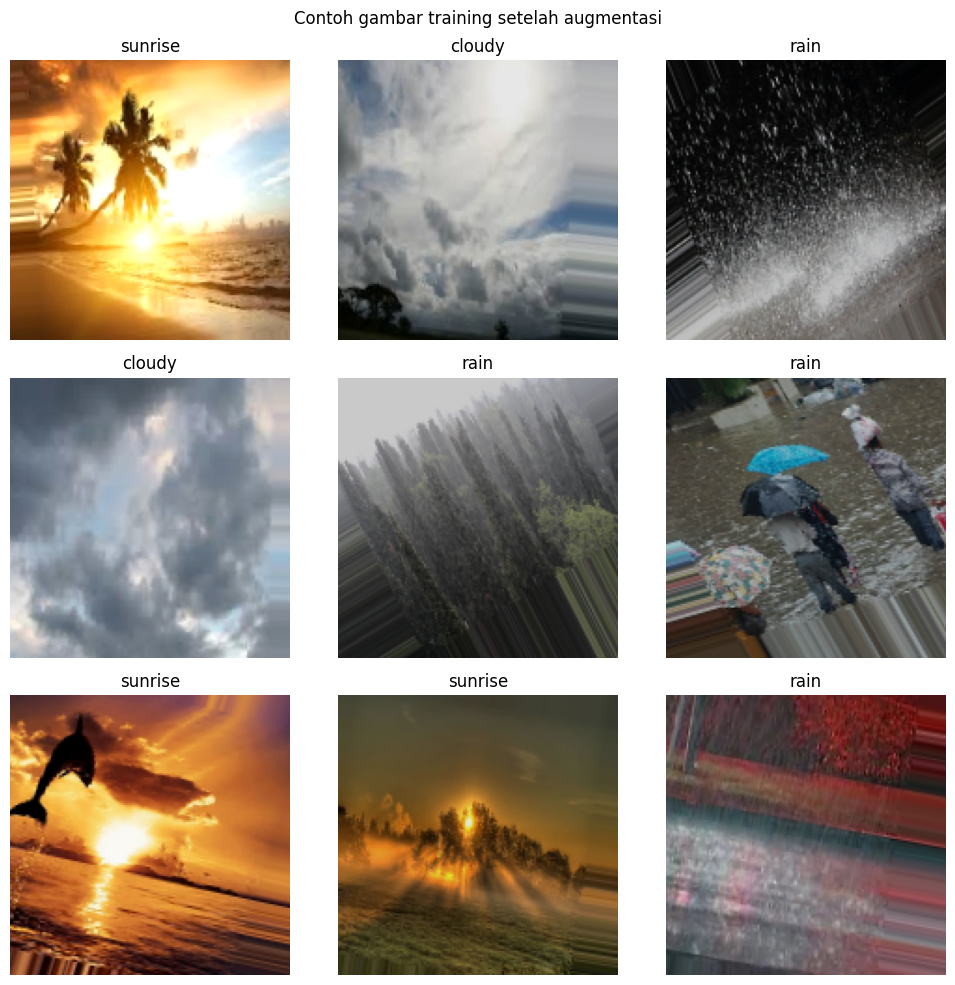

In [9]:
# Visualisasi contoh gambar hasil augmentasi
sample_images, sample_labels = next(train_generator)
class_names_list = list(CLASS_INDICES.keys())

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    label_idx = np.argmax(sample_labels[i])
    plt.title(class_names_list[label_idx])
    plt.axis("off")
plt.suptitle("Contoh gambar training setelah augmentasi")
plt.tight_layout()
plt.show()

## Modelling

In [10]:
# ============================================================
# Arsitektur CNN: Sequential + Conv2D + Pooling Layer
# ============================================================
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,553,220 (21.18 MB)

 Trainable params: 5,552,516 (21.18 MB)

 Non-trainable params: 704 (2.75 KB)

In [11]:
# ============================================================
# Callback kustom: hentikan training otomatis begitu akurasi
# train & validation sudah mencapai target (menerapkan callback = poin bonus)
# ============================================================
class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_acc=0.96, target_val_acc=0.96):
        super().__init__()
        self.target_acc = target_acc
        self.target_val_acc = target_val_acc

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get("accuracy", 0)
        val_acc = logs.get("val_accuracy", 0)
        if acc >= self.target_acc and val_acc >= self.target_val_acc:
            print(
                f"\nAkurasi training ({acc:.4f}) dan validation ({val_acc:.4f}) "
                f"sudah mencapai target, training dihentikan pada epoch {epoch + 1}."
            )
            self.model.stop_training = True


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12, restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
)

acc_threshold_cb = AccuracyThresholdCallback(target_acc=0.96, target_val_acc=0.96)

# Class weight untuk menangani ketidakseimbangan jumlah gambar antar kelas
labels_int = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(labels_int), y=labels_int
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.9357142857142857), 1: np.float64(1.31), 2: np.float64(1.1101694915254237), 3: np.float64(0.7891566265060241)}


In [12]:
# ============================================================
# Training
# ============================================================
EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[acc_threshold_cb, early_stop, reduce_lr],
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 684ms/step - accuracy: 0.6756 - loss: 3.3805 - val_accuracy: 0.3604 - val_loss: 2.4819 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 333ms/step - accuracy: 0.7837 - loss: 1.3578 - val_accuracy: 0.2973 - val_loss: 3.6971 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step - accuracy: 0.8168 - loss: 0.8571 - val_accuracy: 0.2703 - val_loss: 4.8347 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 295ms/step - accuracy: 0.8308 - loss: 0.7730 - val_accuracy: 0.3514 - val_loss: 5.5866 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step - accuracy: 0.8092 - loss: 0.7019 - val_accuracy: 0.4324 - val_loss: 2.8221 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step - accuracy: 0.8181 - loss: 0.6342 - val_accuracy: 0.3153 - val_loss: 3.2130 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.8372 - loss: 0.7813 -

## Evaluasi dan Visualisasi

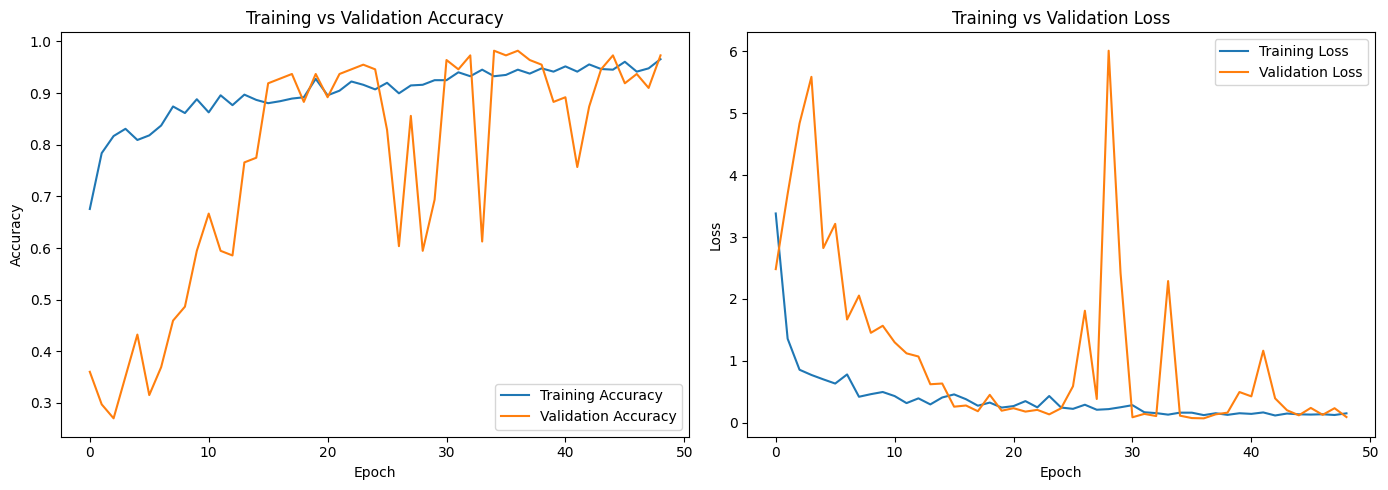

In [13]:
# ============================================================
# Plot akurasi & loss selama training
# ============================================================
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Evaluasi akhir pada train, validation, dan test set
# ============================================================
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss_f, val_acc_f = model.evaluate(val_generator, verbose=0)
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

print(f"Train      -> loss: {train_loss:.4f} | accuracy: {train_acc:.4f}")
print(f"Validation -> loss: {val_loss_f:.4f} | accuracy: {val_acc_f:.4f}")
print(f"Test       -> loss: {test_loss:.4f} | accuracy: {test_acc:.4f}")

print("\nStatus kriteria wajib (akurasi train & test >= 85%):",
      "TERPENUHI" if train_acc >= 0.85 and test_acc >= 0.85 else "BELUM terpenuhi")
print("Status bonus (akurasi train & test >= 95%):",
      "TERPENUHI" if train_acc >= 0.95 and test_acc >= 0.95 else "belum")

Train      -> loss: 0.0911 | accuracy: 0.9631
Validation -> loss: 0.0723 | accuracy: 0.9820
Test       -> loss: 0.2728 | accuracy: 0.9211

Status kriteria wajib (akurasi train & test >= 85%): TERPENUHI
Status bonus (akurasi train & test >= 95%): belum


              precision    recall  f1-score   support

      cloudy       0.98      0.73      0.84        60
        rain       0.92      1.00      0.96        44
       shine       0.81      0.98      0.88        51
     sunrise       0.99      0.99      0.99        73

    accuracy                           0.92       228
   macro avg       0.92      0.93      0.92       228
weighted avg       0.93      0.92      0.92       228



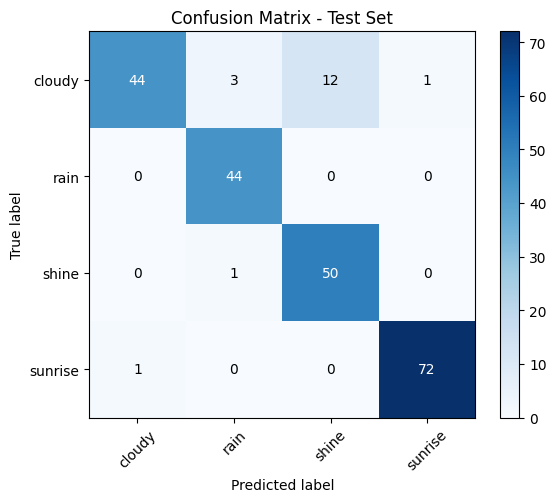

In [15]:
# Confusion matrix & classification report sebagai bukti evaluasi tambahan
from sklearn.metrics import classification_report, confusion_matrix
import itertools

test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names_list))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.colorbar()
tick_marks = np.arange(len(class_names_list))
plt.xticks(tick_marks, class_names_list, rotation=45)
plt.yticks(tick_marks, class_names_list)
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center", va="center",
              color="white" if cm[i, j] > thresh else "black")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## Konversi Model

In [16]:
# ============================================================
# 1. Simpan dalam format SavedModel
# ============================================================
SAVED_MODEL_DIR = "/content/submission/saved_model"
os.makedirs("/content/submission", exist_ok=True)
if os.path.exists(SAVED_MODEL_DIR):
    shutil.rmtree(SAVED_MODEL_DIR)

tf.saved_model.save(model, SAVED_MODEL_DIR)
print("SavedModel tersimpan di:", SAVED_MODEL_DIR)

SavedModel tersimpan di: /content/submission/saved_model


In [17]:
# ============================================================
# 2. Konversi ke TensorFlow Lite (TF-Lite)
# ============================================================
TFLITE_DIR = "/content/submission/tflite"
os.makedirs(TFLITE_DIR, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = os.path.join(TFLITE_DIR, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

label_path = os.path.join(TFLITE_DIR, "label.txt")
inv_class_indices = {v: k for k, v in CLASS_INDICES.items()}
with open(label_path, "w") as f:
    for i in range(NUM_CLASSES):
        f.write(inv_class_indices[i] + "\n")

print("TF-Lite model tersimpan di:", tflite_path)
print("Label tersimpan di        :", label_path)

TF-Lite model tersimpan di: /content/submission/tflite/model.tflite
Label tersimpan di        : /content/submission/tflite/label.txt


In [18]:
# ============================================================
# 3. Konversi ke TensorFlow.js (TFJS)
# ============================================================
TFJS_DIR = "/content/submission/tfjs_model"
!tensorflowjs_converter --input_format=tf_saved_model {SAVED_MODEL_DIR} {TFJS_DIR}
print("TFJS model tersimpan di:", TFJS_DIR)

2026-07-30 10:47:54.571917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785408474.604647    3921 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785408474.616254    3921 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785408474.640971    3921 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785408474.640997    3921 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785408474.641002    3921 computation_placer.cc:177] computation placer alr

In [19]:
# ============================================================
# Salin notebook & buat requirements.txt, lalu zip seluruh submission
# ============================================================
requirements_txt = """tensorflow==2.17.0
tensorflowjs==4.20.0
split-folders==0.5.1
numpy
pandas
matplotlib
pillow
scikit-learn
kaggle
"""

with open("/content/submission/requirements.txt", "w") as f:
    f.write(requirements_txt)

print("requirements.txt dibuat.")
print(
    "\nJangan lupa: setelah semua cell dijalankan, download folder /content/submission "
    "(tambahkan notebook.ipynb dan README.md ke dalamnya), lalu kompres menjadi .zip sebelum submit."
)

!ls -R /content/submission

requirements.txt dibuat.

Jangan lupa: setelah semua cell dijalankan, download folder /content/submission (tambahkan notebook.ipynb dan README.md ke dalamnya), lalu kompres menjadi .zip sebelum submit.
/content/submission:
requirements.txt  saved_model  tfjs_model  tflite

/content/submission/saved_model:
assets	fingerprint.pb	saved_model.pb	variables

/content/submission/saved_model/assets:

/content/submission/saved_model/variables:
variables.data-00000-of-00001  variables.index

/content/submission/tfjs_model:
group1-shard1of6.bin  group1-shard3of6.bin  group1-shard5of6.bin  model.json
group1-shard2of6.bin  group1-shard4of6.bin  group1-shard6of6.bin

/content/submission/tflite:
label.txt  model.tflite


## Inference (Optional)